
# Lab Assignment 17: Climate Change—Temperatures and Precipitation

In this project, you will investigate data on climate change, or the long-term shifts in temperatures and weather patterns!

---

In [57]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
texlive is already the newest version (2021.20220204-1).
texlive-latex-extra is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [58]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# Run this cell to set up the notebook, but please don't change it.
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
np.set_printoptions(legacy='1.13')

import warnings
warnings.simplefilter('ignore')

import plotly.graph_objects as go

## Part 1: Temperatures

In the following analysis, we will investigate one of the 21st century's most prominent issues: climate change. While the details of climate science are beyond the scope of this course, we can start to learn about climate change just by analyzing public records of different cities' temperature and precipitation over time.

We will analyze a collection of historical daily temperature and precipitation measurements from weather stations in 210 U.S. cities. The dataset was compiled by Yuchuan Lai and David Dzombak [1]; a description of the data from the original authors and the data itself is available [here](https://kilthub.cmu.edu/articles/dataset/Compiled_daily_temperature_and_precipitation_data_for_the_U_S_cities/7890488).

[1] Lai, Yuchuan; Dzombak, David (2019): Compiled historical daily temperature and precipitation data for selected 210 U.S. cities. Carnegie Mellon University. Dataset.

### Part 1, Section 1: Cities

Run the following cell to load information about the `cities` and preview the first few rows.

In [60]:
cities = Table.read_table('./DS/city_info.csv', index_col=0)
cities.show(3)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31


The `cities` table has one row per weather station and the following columns:

1. `"Name"`: The name of the US city
2. `"ID"`: The unique identifier for the US city
3. `"Lat"`: The latitude of the US city (measured in degrees of latitude)
4. `"Lon"`: The longitude of the US city (measured in degrees of longitude)
4. `"Stn.Name"`: The name of the weather station in which the data was collected
5. `"Stn.stDate"`: A string representing the date of the first recording at that particular station
6. `"Stn.edDate"`: A string representing the date of the last recording at that particular station

The data lists the weather stations at which temperature and precipitation data were collected. Note that although some cities have multiple weather stations, only one is collecting data for that city at any given point in time. Thus, we are able to just focus on the cities themselves.

**Question 1.1.1:** In the cell below, produce a scatter plot that plots the latitude and longitude of every city in the `cities` table so that the result places northern cities at the top and western cities at the left.

*Note*: It's okay to plot the same point multiple times!

*Hint*: A latitude is the set of horizontal lines that measures distances *north or south* of the equator. A longitude is the set of vertical lines that measures distances *east or west* of the prime meridian.


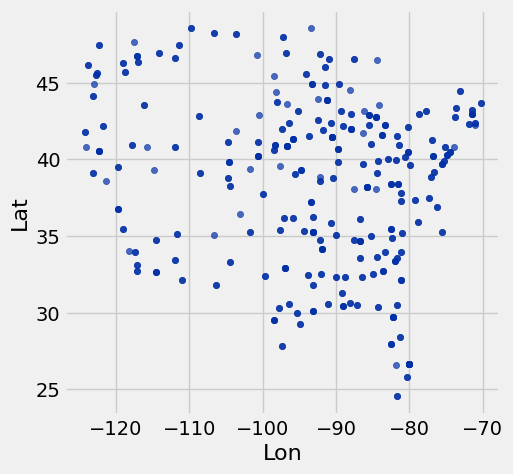

In [61]:
cities.scatter('Lon', 'Lat')

These cities are all within the continental U.S., and so the general shape of the U.S. should be visible in your plot. The shape will appear distorted compared to most maps for two reasons: the scatter plot is square even though the U.S. is wider than it is tall, and this scatter plot is an [equirectangular projection](https://en.wikipedia.org/wiki/Equirectangular_projection) of the spherical Earth. A geographical map of the same data uses the common [Pseudo-Mercator projection](https://en.wikipedia.org/wiki/Web_Mercator_projection).

In [62]:
# Just run this cell
fig = go.Figure(data=go.Scattergeo(
        lon = cities.column('Lon'),
        lat = cities.column('Lat'),
        text = cities.column('Name'),
        mode = 'markers'))

fig.update_layout(geo_scope='usa', width=800, height=500, margin={'r': 0, 't': 0, 'l': 0, 'b': 0})
fig.show()

**Question 1.1.2** Does it appear that these city locations are sampled uniformly at random from all the locations in the U.S.? Why or why not?


Looking at the scatterplot, cities appear to be spread across the United States, but they appear to be more concentrated in certain areas. Therefore, the location of cities can be a valuable resource for the United States. This could potentially have an impact.

**Question 1.1.3:** Assign `num_unique_cities` to the number of unique cities that appear in the `cities` table.


In [63]:
num_unique_cities = cities.group('Name').num_rows

# Do not change this line
print(f"There are {num_unique_cities} unique cities that appear within our dataset.")

There are 210 unique cities that appear within our dataset.


In order to investigate further, it will be helpful to determine what region of the United States each city was located in: Northeast, Northwest, Southeast, or Southwest. For our purposes, we will be using the following geographical boundaries:

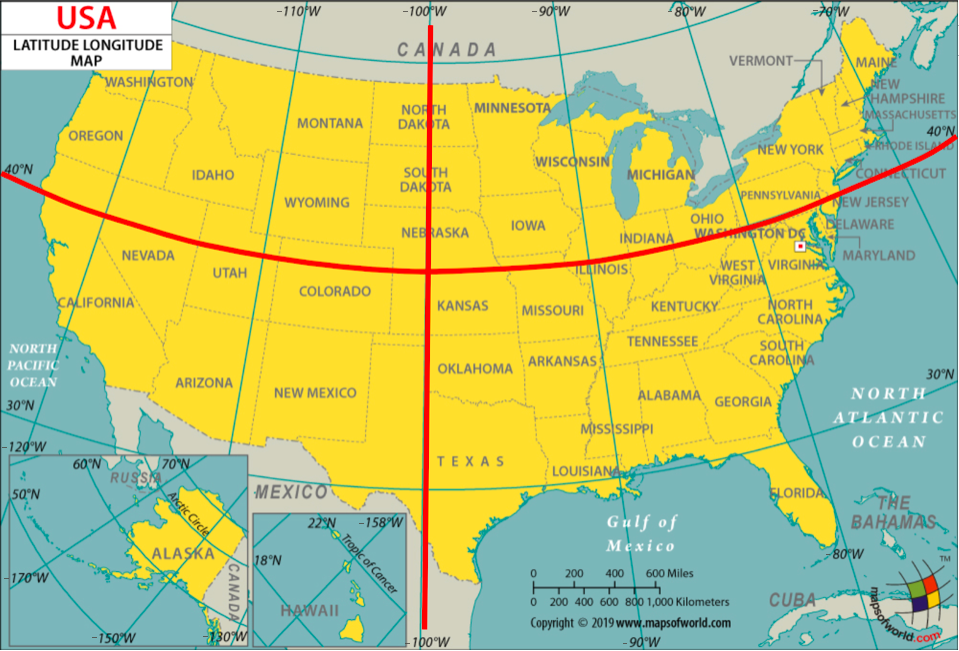

1. A station is located in the `"Northeast"` region if its latitude is above or equal to 40 degrees and its longtitude is greater than or equal to -100 degrees.
2. A station is located in the `"Northwest"` region if its latitude is above or equal to 40 degrees and its longtitude is less than -100 degrees.
3. A station is located in the `"Southeast"` region if its latitude is below 40 degrees and its longtitude is greater than or equal to -100 degrees.
4. A station is located in the `"Southwest"` region if its latitude is below 40 degrees and its longtitude is less than -100 degrees.

**Question 1.1.4**: Define the `coordinates_to_region` function below. It should take in two arguments, a city's latitude (`lat`) and longitude (`lon`) coordinates, and output a string representing the region it is located in.


In [64]:
def coordinates_to_region(lat, lon):
    if lat >= 40 and lon >= -100:
        return "Northeast"
    elif lat >= 40 and lon < -100:
        return "Northwest"
    elif lat < 40 and lon >= -100:
        return "Southeast"
    elif lat < 40 and lon < -100:
        return "Southwest"

**Question 1.1.5**: Add a new column in `cities` labeled `Region` that contains the region in which the city is located. For full credit, you must use the `coordinates_to_region` function you defined rather than reimplementing its logic.


In [65]:
regions_array = cities.apply(coordinates_to_region, 'Lat', 'Lon')
cities = cities.with_column('Region', regions_array)
cities.show(5)



Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate,Region
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28,Northwest
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31,Northwest
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31,Northwest
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE MUNICIPAL ARPT,1935-09-01,2021-12-31,Northwest
Wausau,USW00014897,44.9258,-89.6256,Wausau Record Herald,1896-01-01,1941-12-31,Northeast


To confirm that you've defined your `coordinates_to_region` function correctly and successfully added the `Region` column to the `cities` table, run the following cell. Each region should have a different color in the result.

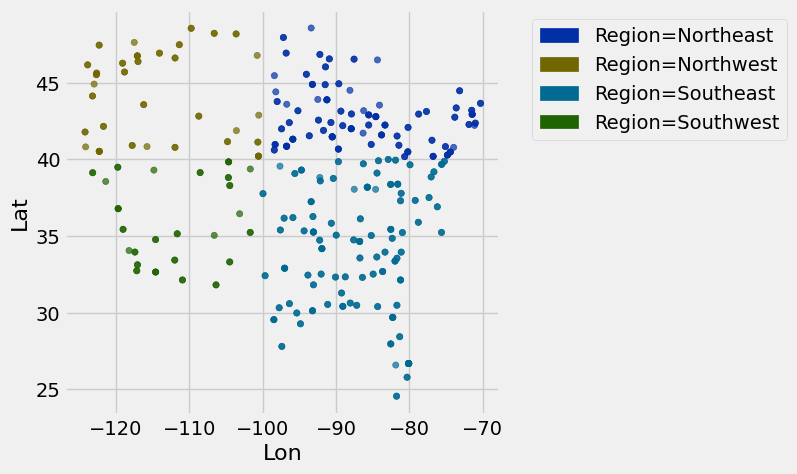

In [66]:
# Just run this cell
cities.scatter("Lon", "Lat", group="Region")

**Challenge Question 1.1.6 (OPTIONAL, ungraded)**: Create a new table called `cities_nearest`. It should contain the same columns as the `cities` table and an additional column called `"Nearest"` that contains the **name of the nearest city** that is in a different region from the city described by the row.

To approximate the distance between two cities, take the square root of the sum of the squared difference between their latitudes and the square difference between their longitudes. Don't use a `for` statement; instead, use the `apply` method and array arithmetic.

*Hint*: We have defined a `distance` function for you, which can be called on numbers `lat0` and `lon0` and arrays `lat1` and `lon1`.

In [67]:
def distance(lat0, lon0, lat1, lon1):
    "Approximate the distance between point (lat0, lon0) and (lat1, lon1) pairs in the arrays."
    return np.sqrt((lat0 - lat1) * (lat0 - lat1) + (lon0 - lon1) * (lon0 - lon1))

# BEGIN SOLUTION
def nearest(name):
    row = cities.where('Name', name).row(0)
    others = cities.where('Region', are.not_equal_to(row.item('Region')))
    distances = distance(row.item('Lat'), row.item('Lon'),
                         others.column('Lat'), others.column('Lon'))
    return others.with_column('dist', distances).sort('dist').row(0).item('Name')

nearest_array = cities.apply(nearest, "Name")
# END SOLUTION

cities_nearest = cities.with_column("Nearest", nearest_array) # SOLUTION
cities_nearest.show(5)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate,Region,Nearest
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28,Northwest,GrandJunction
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31,Northwest,GrandJunction
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31,Northwest,Denver
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE MUNICIPAL ARPT,1935-09-01,2021-12-31,Northwest,Denver
Wausau,USW00014897,44.9258,-89.6256,Wausau Record Herald,1896-01-01,1941-12-31,Northeast,Springfield


### Part 1, Section 2: Welcome to Phoenix, Arizona

Each city has a different CSV file full of daily temperature and precipitation measurements. The file for Phoenix, Arizona is included with this project as `phoenix.csv`. The files for other cities can be downloaded [here](https://kilthub.cmu.edu/articles/dataset/Compiled_daily_temperature_and_precipitation_data_for_the_U_S_cities/7890488) by matching them to the ID of the city in the `cities` table.

Since Phoenix is located on the upper edge of the Sonoran Desert, it has some impressive temperatures.

Run the following cell to load in the `phoenix` table. It has one row per day and the following columns:

1. `"Date"`: The date (a string) representing the date of the recording in **YYYY-MM-DD** format
2. `"tmax"`: The maximum temperature for the  day (°F)
3. `"tmin"`: The minimum temperature for the day (°F)
4. `"prcp"`: The recorded precipitation for the day (inches)

In [68]:
phoenix = Table.read_table("./DS/phoenix.csv", index_col=0)
phoenix.show(3)

Date,tmax,tmin,prcp
1896-01-01,66,30,0
1896-01-02,64,30,0
1896-01-03,68,30,0


**Question 1.2.1:** Assign the variable `largest_2010_range_date` to the date of the **largest temperature range** in Phoenix, Arizona for any day between January 1st, 2010 and December 31st, 2010. To get started, use the variable `phoenix_with_ranges_2010` to filter the phoenix table to days in 2010 with an additional column corresponding to the temperature range for that day.

**Your answer should be a string in the "YYYY-MM-DD" format.** Feel free to use as many lines as you need. A temperature range is calculated as the difference between the max and min temperatures for the day.

*Hint*: To limit the values in a column to only those that *contain* a certain string, pick the right `are.` predicate from the [Python Reference Sheet](https://www.data8.org/sp24/reference/#table-filtering-predicates).

*Note:* Do **not** re-assign the `phoenix` variable; please use the `phoenix_with_ranges_2010` variable instead.


In [69]:
phoenix_with_ranges = phoenix.with_column('range', phoenix.column('tmax') - phoenix.column('tmin'))
phoenix_with_ranges_2010 = phoenix_with_ranges.where('Date', are.containing('2010'))
largest_2010_range_date = phoenix_with_ranges_2010.sort('range', descending=True).column('Date').item(0)
largest_2010_range_date

'2010-06-24'

We can look back to our `phoenix` table to check the temperature readings for our `largest_2010_range_date` to see if anything special is going on. Run the cell below to find the row of the `phoenix` table that corresponds to the date we found above.

In [70]:
# Just run this cell
phoenix.where("Date", largest_2010_range_date)

Date,tmax,tmin,prcp
2010-06-24,113,79,0


ZOO WEE MAMA! Look at the maximum temperature for that day. That's hot.

The function `extract_year_from_date` takes a date string in the **YYYY-MM-DD** format and returns an integer representing the **year**. The function `extract_month_from_date` takes a date string and returns a string describing the month. Run this cell, but you do not need to understand how this code works or edit it.

In [71]:
# Just run this cell
import calendar

def extract_year_from_date(date):
    """Returns an integer corresponding to the year of the input string's date."""
    return int(date[:4])

def extract_month_from_date(date):
    "Return an abbreviation of the name of the month for a string's date."
    month = date[5:7]
    return f'{month} ({calendar.month_abbr[int(date[5:7])]})'


# Example
print('2022-04-01 has year', extract_year_from_date('2022-04-01'),
      'and month', extract_month_from_date('2022-04-01'))

2022-04-01 has year 2022 and month 04 (Apr)


**Question 1.2.2:** Add two new columns called `Year` and `Month` to the `phoenix` table that contain the year as an **integer** and the month as a **string** (such as `"04 (Apr)"`) for each day, respectively.

*Note*: The functions above may be helpful!


In [72]:
years_array = phoenix.apply(extract_year_from_date, 'Date')
months_array = phoenix.apply(extract_month_from_date, 'Date')
phoenix = phoenix.with_columns('Year', years_array, 'Month', months_array)
phoenix.show(5)

Date,tmax,tmin,prcp,Year,Month
1896-01-01,66,30,0,1896,01 (Jan)
1896-01-02,64,30,0,1896,01 (Jan)
1896-01-03,68,30,0,1896,01 (Jan)
1896-01-04,69,34,0,1896,01 (Jan)
1896-01-05,70,46,0,1896,01 (Jan)


**Question 1.2.3:** Using the `phoenix` table, create an overlaid line plot of the **average maximum temperature** and **average minimum temperature** for each year between 1900 and 2020 (inclusive).

*Hint:* To draw a line plot with more than one line, call `plot` on the column label of the x-axis values and all other columns will be treated as y-axis values.


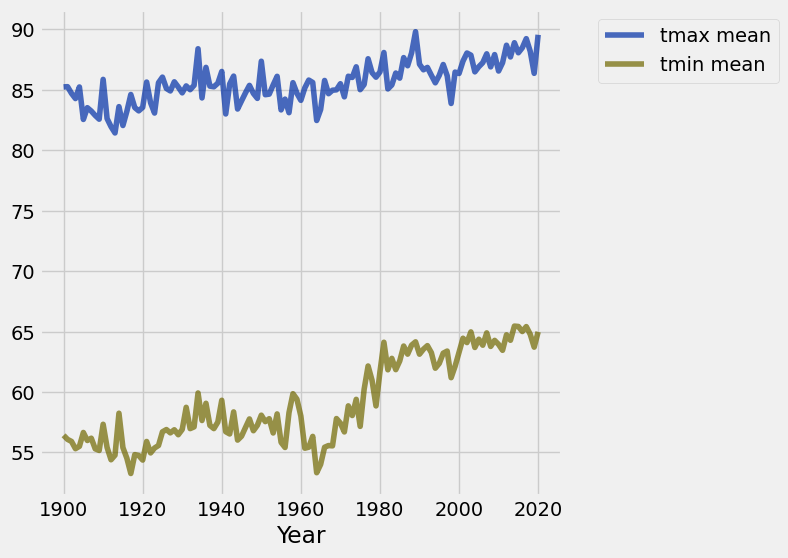

In [73]:
avg_temps_by_year = phoenix.group('Year', np.mean).select('Year', 'tmax mean', 'tmin mean')
avg_temps_1900To2020 = avg_temps_by_year.where('Year', are.between_or_equal_to(1900, 2020))
avg_temps_1900To2020.plot('Year')

**Question 1.2.4:** Although still hotly debated (pun intended), many climate scientists agree that the effects of climate change began to surface in the early 1960s as a result of elevated levels of greenhouse gas emissions. How does the graph you produced in Question 1.2.3 support the claim that modern-day global warming began in the early 1960s?


Looking at the graph generated in question 1.2.3, both the average annual maximum temperature and climate in Phoenix show a notable trend starting in the 1960s. Before the 1960s, there was an internal trend of change. However, since the 1960s, more eruptions have occurred in the northern region. These observations may provide evidence, as many argue, that human activity has begun to impact the Earth since the 1960s.

Averaging temperatures across an entire year can obscure some effects of climate change. For example, if summers get hotter but winters get colder, the annual average may not change much. Let's investigate how average **monthly** maximum temperatures have changed over time in Phoenix.

**Question 1.2.5:** Create a `monthly_increases` table with one row per month and the following four columns in order:
1. `"Month"`: The month (such as `"02 (Feb)"`)
2. `"Past"`: The average max temperature in that month from 1900-1960 (both ends inclusive)
3. `"Present"`: The average max temperature in that month from 2019-2021 (both ends inclusive)
4. `"Increase"`: The difference between the present and past average max temperatures in that month

First make a copy of the `phoenix` table and add a new column containing the corresponding **period** for each row. You may find the `period` function helpful. Then, use this new table to construct `monthly_increases`. Feel free to use as many lines as you need.

*Hint*: What table method can we use to get each **unique value** as its own column?

*Note*: Please do **not** re-assign the `phoenix` variable!


In [74]:
def period(year):
    "Output if a year is in the Past, Present, or Other."
    if 1900 <= year <= 1960:
        return "Past"
    elif 2019 <= year <= 2021:
        return "Present"
    else:
        return "Other"

phoenix_with_period = phoenix.with_column('Period', phoenix.apply(period, 'Year'))

monthly_avg_tmax = phoenix_with_period.where('Period', are.not_equal_to('Other')).group(['Month', 'Period'], np.mean).select('Month', 'Period', 'tmax mean')

past_temps = monthly_avg_tmax.where('Period', 'Past').select('Month', 'tmax mean').relabeled('tmax mean', 'Past')
present_temps = monthly_avg_tmax.where('Period', 'Present').select('Month', 'tmax mean').relabeled('tmax mean', 'Present')

monthly_increases = past_temps.join('Month', present_temps)
monthly_increases = monthly_increases.with_columns('Increase', monthly_increases.column('Present') - monthly_increases.column('Past'))
monthly_increases.show()

Month,Past,Present,Increase
01 (Jan),65.0164,67.8312,2.81479
02 (Feb),68.8485,69.1859,0.337362
03 (Mar),74.6499,75.9796,1.32965
04 (Apr),82.6421,88.4,5.75792
05 (May),91.4299,94.571,3.14104
06 (Jun),101.166,105.734,4.56832
07 (Jul),103.599,107.245,3.64654
08 (Aug),101.416,107.384,5.96769
09 (Sep),97.6874,101.238,3.55035
10 (Oct),86.798,90.1667,3.36868


## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [76]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab17(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab17(SSU).ipynb to pdf
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
[NbConvertApp] Support files will be in lab17(SSU)_files/
[NbConvertApp] Making directory ./lab17(SSU)_files
[NbConvertApp] Writing 65041 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 208971 bytes to DS/lab17(SSU).pdf
